<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

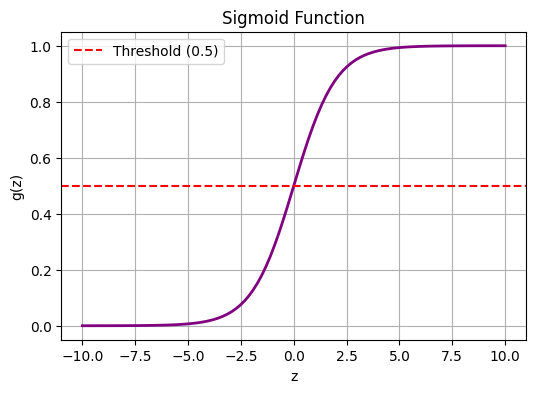

w1: 0.9372461822457652
w2: 0.21911677102172292
b: -18.164218868062964
z = -2.4011870344542245
result : 0.08308222395812291
s_result : 0.08308222395812291
accuracy Score: 0.9064327485380117
              precision    recall  f1-score   support

           B       0.90      0.95      0.93       108
           M       0.91      0.83      0.87        63

    accuracy                           0.91       171
   macro avg       0.91      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171



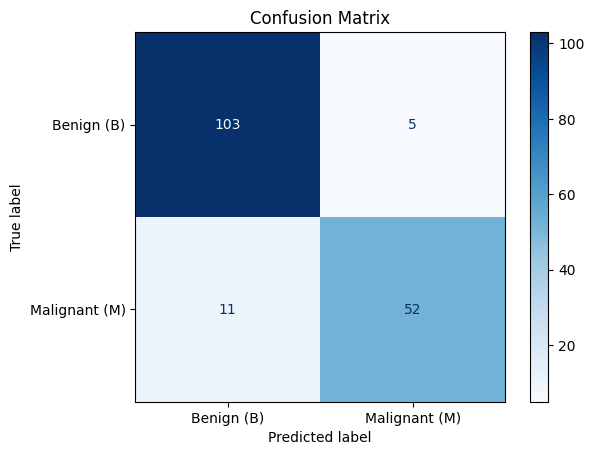

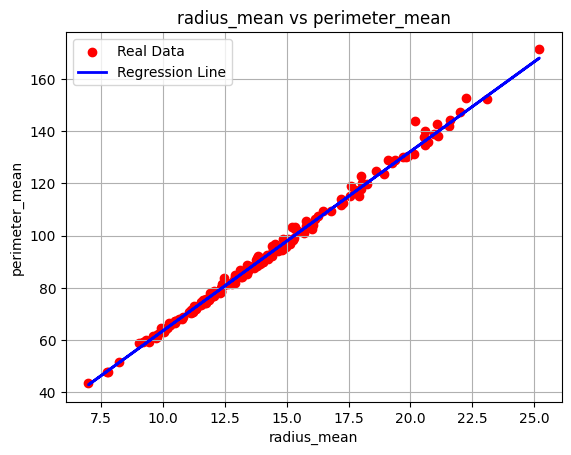

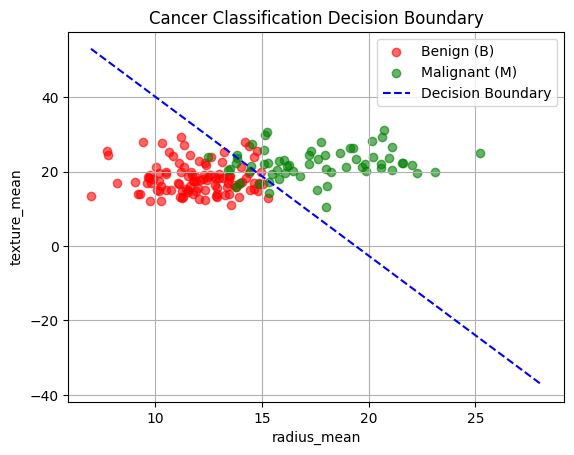

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score, ConfusionMatrixDisplay
)


df = pd.read_csv("data.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()


cols = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean"]
for col in cols:
    zero_count = (df[col] == 0).sum()
    print(col, " ", zero_count)
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)

print("zeros were replaced with the median")

X = df[["radius_mean"]]
y = df["perimeter_mean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MES:", mse)
print("R2:", r2)
m = model.coef_[0]
c = model.intercept_
print("01:", m)
print("00:", c)
print(": y_hat =", m, "* X +", c)



def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 100)
plt.figure(figsize=(6, 4))
plt.plot(z_values, sigmoid(z_values), color='purple', linewidth=2)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("g(z)")
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.grid(True)
plt.legend()
plt.show()

X2 = df[["radius_mean", "texture_mean"]]
y2 = df["diagnosis"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

log_model = LogisticRegression()
log_model.fit(X2_train, y2_train)
w1 = log_model.coef_[0][0]
w2 = log_model.coef_[0][1]
b = log_model.intercept_[0]
print("w1:", w1)
print("w2:", w2)
print("b:", b)

sample = X2_test.iloc[[0]]
X1_value = sample["radius_mean"].values[0]
X2_value = sample["texture_mean"].values[0]

z = w1 * X1_value + w2 * X2_value + b

result = sigmoid(z)

s_result = log_model.predict_proba(sample)[0][1]

print("z =", z)
print("result :", result)
print("s_result :", s_result)

y2_pred = log_model.predict(X2_test)
acc = accuracy_score(y2_test, y2_pred)
print("accuracy Score:", acc)

print(classification_report(y2_test, y2_pred))

cm = confusion_matrix(y2_test, y2_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (B)", "Malignant (M)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

plt.scatter(X_test, y_test, color="red", label="Real Data")
plt.plot(X_test, y_pred, color="blue", linewidth=2, label="Regression Line")

plt.title("radius_mean vs perimeter_mean")
plt.xlabel("radius_mean")
plt.ylabel("perimeter_mean")
plt.legend()
plt.grid(True)
plt.show()

plt.scatter(X2_test[y2_test == 'B']["radius_mean"], X2_test[y2_test == 'B']["texture_mean"], color="red", label="Benign (B)", alpha=0.6)
plt.scatter(X2_test[y2_test == 'M']["radius_mean"], X2_test[y2_test == 'M']["texture_mean"], color="green", label="Malignant (M)", alpha=0.6)

x1_boundary = np.linspace(X2["radius_mean"].min(), X2["radius_mean"].max(), 100)
x2_boundary = -(w1 * x1_boundary + b) / w2

plt.plot(x1_boundary, x2_boundary, color="blue", linestyle="--", label="Decision Boundary")

plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.title("Cancer Classification Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv
